<a href="https://colab.research.google.com/github/husseinlopez/IAdesdeCero2026/blob/main/5.2%20-%20Clasificacion_imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# **Curso IA desde Cero**

* Dr. Irvin Hussein López Nava
* M.C. Joan M. Raygoza Romero

## Librerias

In [1]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
from skimage.feature import hog
import os
import pandas as pd

## Cargar Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Funciones

### Hog
Descriptor que representa una imagen mediante los patrones de bordes y contornos.

En lugar de usar los valores de los píxeles, HOG analiza cómo cambian las intensidades para obtener orientaciones de gradiente en pequeñas regiones (celdas).

El proceso es:

1. Calcular gradientes en cada píxel (dirección y magnitud del cambio de intensidad).
2. Agrupar los gradientes en celdas.
3. Construir histogramas de orientaciones en cada celda.
4. Normalizar por bloques para que sea robusto a iluminación.
5. Concatenar todos los histogramas → vector final de características.

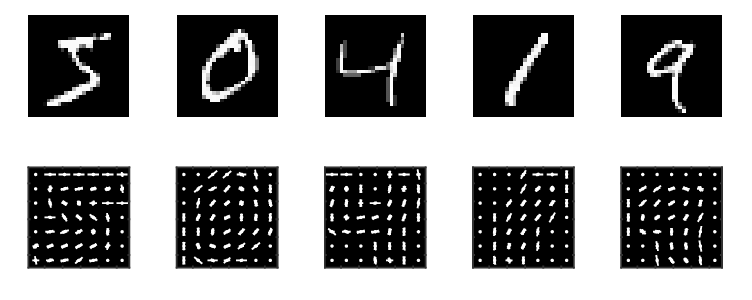

In [2]:
def hog_features(img):
    #img: imagen en escala de grises (2D)
    features = hog(
        img,
        orientations=6,
        pixels_per_cell=(7, 7),
        cells_per_block=(4, 4),
        block_norm='L2-Hys'
    )
    return features

### Momentos Hu
Son un conjunto de 7 valores numéricos que describen la forma global de un objeto en una imagen.

Son como resúmenes matemáticos de la forma.

Se calculan a partir de los momentos geométricos de la imagen y tienen una propiedad muy importante.

Son invariantes a:

* traslación (si se mueve el objeto)
* rotación (si gira)
* escala (si cambia de tamaño)

In [3]:
def hu_moments(img):
    #img: imagen en escala de grises (2D)
    moments = cv2.moments(img)
    hu = cv2.HuMoments(moments).flatten()  # 7 momentos

    # Suele aplicarse log para estabilizar los valores
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-7)

    return hu_log  # tamaño = 7

### Extracción de características

In [4]:
def extract_features(img):
    f_hog = hog_features(img)                   # 96
    f_hu = hu_moments(img)                      # 7

    # Vector final de características
    features = np.concatenate([f_hog, f_hu])
    return features  # tamaño total = 96 + 7 = 103


## Path de donde estan mis imagenes

In [8]:
base_path = 'drive/MyDrive/IA desde cero/mnist_digits/'

### Extracción de características por cada imagen

In [15]:
imgs_flatten = []
features = []
labels = []
for class_name in os.listdir(base_path):
    print(class_name)
    for image_name in os.listdir(base_path + class_name):
        filename = base_path + class_name + '/' + image_name
        img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
        imgs_flatten.append(img.flatten())
        features.append(extract_features(img))
        labels.append(class_name)

1
2
0
7
8
4
3
9
5
6


### Creación del conjunto de datos

### Imagenes aplanadas

In [17]:
imgs_df = pd.DataFrame(imgs_flatten, columns=[str(i) for i in range(784)])
imgs_df['label'] = labels
imgs_df.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,1,5,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


### Características que resumen la imagen

In [18]:
features_df = pd.DataFrame(features, columns=['hog_'+str(i) for i in range(96)]+['hu_'+str(i) for i in range(7)])
features_df['label'] = labels
features_df.head()

,hog_0,hog_1,hog_2,hog_3,hog_4,hog_5,hog_6,hog_7,hog_8,hog_9,...,hog_94,hog_95,hu_0,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.020163,0.010259,0.008588,0.014191,...,0.0,0.000000,2.591009,5.255832,6.997977,6.999503,7.0,7.000000,-7.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,2.514119,5.086354,6.996480,6.999259,-7.0,-6.999999,7.0,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.292945,0.000000,0.069069,0.110371,...,0.0,0.000000,2.726980,5.529930,6.998986,6.999540,7.0,6.999999,-7.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.232970,0.084707,0.002052,0.050677,...,0.0,0.001905,2.603308,5.288611,6.998330,6.999544,7.0,6.999999,7.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,2.295334,4.637880,6.996566,6.995931,7.0,6.999982,7.0,1


### Guardar el conjunto de datos

In [19]:
imgs_df.to_csv('mnist_digits_img.csv', index=False)

In [20]:
features_df.to_csv('mnist_digits_features.csv', index=False)